In [2]:
import xarray as xr
import rioxarray
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import lightgbm as lgb 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter
from tqdm import tqdm

In [3]:
ds = xr.open_dataset("../data/silver/ashanti-2021.nc", decode_coords="all")
print(ds)

<xarray.Dataset> Size: 8GB
Dimensions:               (y: 19647, x: 24608)
Coordinates:
  * y                     (y) float64 157kB 7.623 7.623 7.622 ... 5.855 5.855
  * x                     (x) float64 197kB -2.452 -2.451 ... -0.2378 -0.2377
    spatial_ref           int64 8B ...
Data variables: (12/14)
    blue                  (y, x) uint8 483MB ...
    green                 (y, x) uint8 483MB ...
    red                   (y, x) uint8 483MB ...
    rededge               (y, x) uint8 483MB ...
    B06                   (y, x) uint8 483MB ...
    B07                   (y, x) uint8 483MB ...
    ...                    ...
    swir11                (y, x) uint8 483MB ...
    swir22                (y, x) uint8 483MB ...
    cloud_confidence      (y, x) uint8 483MB ...
    scene_classification  (y, x) uint8 483MB ...
    valid_observations    (y, x) uint8 483MB ...
    ethz_map              (y, x) float32 2GB ...


EPSG:4326


<Axes: ylabel='Count'>

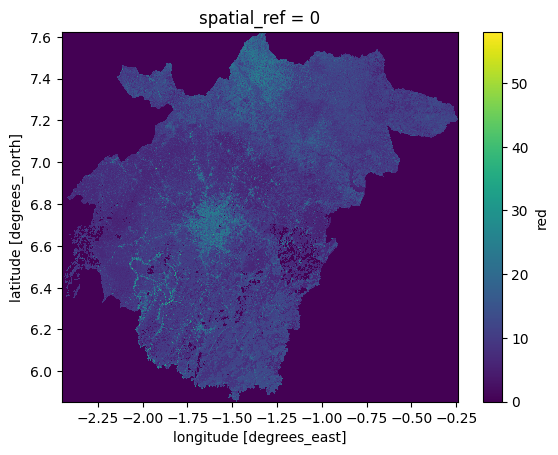

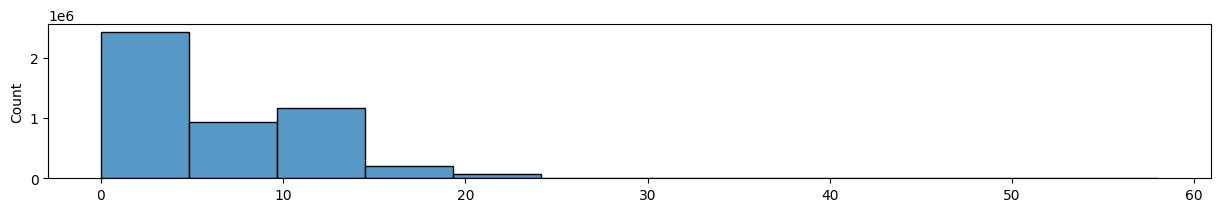

In [4]:
# Check CRS and resolution
print(ds.rio.crs)

# Downsample & plot
step = 10
ds_small = ds.isel(y=slice(None, None, step), x=slice(None, None, step))
ds_small.red.plot()

plt.figure(figsize=(15,2))
sns.histplot(ds_small.red.values.ravel(), binwidth=5)

In [5]:
# Reduce the amount of data
step = 10
ds = ds.isel(y=slice(None, None, step), x=slice(None, None, step))

# Convert to df

In [6]:
ds.data_vars

Data variables:
    blue                  (y, x) uint8 5MB ...
    green                 (y, x) uint8 5MB ...
    red                   (y, x) uint8 5MB ...
    rededge               (y, x) uint8 5MB ...
    B06                   (y, x) uint8 5MB ...
    B07                   (y, x) uint8 5MB ...
    nir                   (y, x) uint8 5MB ...
    B8A                   (y, x) uint8 5MB ...
    swir11                (y, x) uint8 5MB ...
    swir22                (y, x) uint8 5MB ...
    cloud_confidence      (y, x) uint8 5MB ...
    scene_classification  (y, x) uint8 5MB ...
    valid_observations    (y, x) uint8 5MB ...
    ethz_map              (y, x) float32 19MB ...

In [6]:
import numpy as np
import pandas as pd
import gc
from pathlib import Path
from tqdm import tqdm
from scipy.ndimage import median_filter, minimum_filter, maximum_filter, uniform_filter

# Define your columns and variables
band_names = ["red", "green", "blue", "rededge", "B06", "B07", "nir", "B8A", "swir11", "swir22"]
aux_names = ["cloud_confidence", "scene_classification", "valid_observations"]
grid_vars = band_names + ["cloud_confidence"]
cols = band_names + aux_names + ["ethz_map"]

chunk_size = 2000
n_chunks = (ds.sizes["y"] + chunk_size - 1) // chunk_size

output_dir = Path("processed_parquet_chunks")
output_dir.mkdir(exist_ok=True)

for i in tqdm(range(0, ds.sizes["y"], chunk_size), total=n_chunks, desc="Processing chunks"):
    
    # 1. Slice chunk with a 2-pixel buffer
    start_y = max(0, i - 2)
    end_y = min(ds.sizes["y"], i + chunk_size + 2)
    chunk_ds = ds[cols].isel(y=slice(start_y, end_y))
    
    valid_start = 0 if i == 0 else 2
    valid_end = None if (i + chunk_size >= ds.sizes["y"]) else -2
    
    # 2. Extract coordinates 
    valid_y_coords = chunk_ds.y.values[valid_start:valid_end]
    valid_x_coords = chunk_ds.x.values
    X, Y = np.meshgrid(valid_x_coords, valid_y_coords)
    
    # ---------------------------------------------------------
    # NEW NODATA MASKING LOGIC
    # Start by assuming we keep every pixel
    keep_mask = np.ones(X.size, dtype=bool)

    # A. Check optical bands (nodata == 0)
    # Flag pixels where ALL optical bands are 0
    all_bands_zero = np.ones(X.size, dtype=bool)
    for band in band_names:
        band_core = chunk_ds[band].values[valid_start:valid_end, :].ravel()
        all_bands_zero &= (band_core == 0)
        del band_core
    
    keep_mask &= ~all_bands_zero
    del all_bands_zero

    # B. Check aux variables (nodata == 255)
    # Drop pixels where ANY auxiliary data is 255
    for aux in aux_names:
        aux_core = chunk_ds[aux].values[valid_start:valid_end, :].ravel()
        keep_mask &= (aux_core != 255)
        del aux_core
    # ---------------------------------------------------------
    
    # If the entire chunk is empty, skip processing it entirely!
    if not keep_mask.any():
        continue
    
    # Initialize dictionary ONLY with the valid pixels
    chunk_data = {
        "lon": X.ravel()[keep_mask],
        "lat": Y.ravel()[keep_mask]
    }
    
    # Clean up coordinate grids
    del X, Y
    
    # 3. Process variables
    for var in cols:
        arr = chunk_ds[var].values 
        
        if var in grid_vars:
            # We MUST cast to float32 here. Running variance/squaring on uint8 
            # will easily overflow 255 and break the math.
            compute_arr = arr.astype(np.float32)
            
            for size in [3, 5]:
                suffix = f"{size}x{size}"
                
                # Filter -> slice buffer -> flatten -> subset valid pixels -> store
                f_med = median_filter(compute_arr, size=size, mode='nearest').astype(arr.dtype)
                chunk_data[f"{var}_{suffix}_median"] = f_med[valid_start:valid_end, :].ravel()[keep_mask]
                del f_med
                
                f_min = minimum_filter(compute_arr, size=size, mode='nearest').astype(arr.dtype)
                chunk_data[f"{var}_{suffix}_min"] = f_min[valid_start:valid_end, :].ravel()[keep_mask]
                del f_min
                
                f_max = maximum_filter(compute_arr, size=size, mode='nearest').astype(arr.dtype)
                chunk_data[f"{var}_{suffix}_max"] = f_max[valid_start:valid_end, :].ravel()[keep_mask]
                del f_max
                
                # Variance Filter
                mean_arr = uniform_filter(compute_arr, size=size, mode='nearest')
                sq_mean_arr = uniform_filter(compute_arr**2, size=size, mode='nearest')
                
                # Var = E[X^2] - (E[X])^2
                f_var = (sq_mean_arr - (mean_arr**2)).astype(arr.dtype)
                f_var = np.clip(f_var, 0, None) 
                
                chunk_data[f"{var}_{suffix}_var"] = f_var[valid_start:valid_end, :].ravel()[keep_mask]
                del mean_arr, sq_mean_arr, f_var
                
            del compute_arr

        # Store the original variable, masked immediately
        chunk_data[var] = arr[valid_start:valid_end, :].ravel()[keep_mask]
        del arr

    # 4. Dump directly to Parquet and wipe the dictionary
    df_chunk = pd.DataFrame(chunk_data)
    df_chunk.to_parquet(output_dir / f"chunk_{i:05d}.parquet")
    
    # 5. Clean house before next loop
    del chunk_data, df_chunk, chunk_ds, keep_mask
    gc.collect()

print("Processing complete!")

Processing chunks: 100%|█| 1/1 [00:

Processing complete!


In [7]:
import dask.dataframe as dd
df = dd.read_parquet("processed_parquet_chunks/*.parquet")
df.head(1)

,lon,lat,red_3x3_median,red_3x3_min,red_3x3_max,red_3x3_var,red_5x5_median,red_5x5_min,red_5x5_max,red_5x5_var,...,cloud_confidence_3x3_max,cloud_confidence_3x3_var,cloud_confidence_5x5_median,cloud_confidence_5x5_min,cloud_confidence_5x5_max,cloud_confidence_5x5_var,cloud_confidence,scene_classification,valid_observations,ethz_map
0,-1.321577,7.622626,11,0,12,21,11,0,15,26,...,0,0,0,0,0,0,0,5,7,0.0


In [8]:
df.compute().to_parquet("../data/silver/Xy.parquet")